<a href="https://colab.research.google.com/github/Gcarmnonapy7/bank_marketing_random_forest_classification/blob/main/UCI_market.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



1.   Data loading

1.   Data cleaning

1.   EDA

1.   Feature engineering

1.   Data splitting

1.   Model training
2.   Model validation


2.   Scoring


2.   Hyperparamets for best model


2.   Save artifact


In [66]:
%pip install ucimlrepo optuna imbalanced-learn

The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. The classification goal is to predict if the client will subscribe a term deposit (variable y).

In [67]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
bank_marketing = fetch_ucirepo(id=222)

# data (as pandas dataframes)
X = bank_marketing.data.features
y = bank_marketing.data.targets

In [68]:
# === import libraries ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")

dataframe = pd.concat([X,y],axis=1)

In [69]:
dataframe['job'].value_counts()

,count
job,
blue-collar,9732
management,9458
technician,7597
admin.,5171
services,4154
retired,2264
self-employed,1579
entrepreneur,1487
unemployed,1303


In [70]:
def isnan_sum(data:pd.DataFrame):
  if data is None:
    return
  # nan ==> not a number

  print("*** Quantity of nan values ***\n")
  for col in data.columns:
    total_variables = len(data)
    count = data[col].isna().sum()
    percent_of_nan = (count /total_variables) * 100
    if count > 0:
      print("=" * 60)
      print(f" Col : {col} and their percent : {percent_of_nan:.2f}")
      print("=" * 60)

isnan_sum(dataframe)


*** Quantity of nan values ***

 Col : job and their percent : 0.64
 Col : education and their percent : 4.11
 Col : contact and their percent : 28.80
 Col : poutcome and their percent : 81.75


In [71]:
# === drop column ===
columns_to_drop = ['poutcome','duration']
dataframe = dataframe.drop(columns=columns_to_drop)

In [72]:
# === drop nan values ===
columns_to_dropna = ['job', 'education']
dataframe = dataframe.dropna(subset=columns_to_dropna)

# === fillnan values (The Correct Way) ===

dataframe['contact'] = dataframe['contact'].fillna("unknown")

In [73]:
len_pdays = len(dataframe['pdays'])
counted_pdays = (dataframe['pdays'] == -1).sum()
percent_pdays = (counted_pdays/len_pdays) * 100
print(f"Percentage of -1 in pdays: {percent_pdays:.2f}%")

Percentage of -1 in pdays: 81.68%


In [74]:
def bind_pdays(val):

  if val == -1:
    return "never_returned"
  elif val <= 30 :
    return "recent"
  elif val <= 60 :
    return "medium"
  elif val <= 90 :
    return "medium_distant"
  else :
    return "distant"

In [75]:
dataframe['frequency_of_contact_pdays'] = dataframe['pdays'].apply(bind_pdays)

mapping_of_frequency = {
    "never_returned": 0,
    "recent": 1,
    "medium": 2,
    "medium_distant": 3,
    "distant" : 4
}

dataframe['frequency_of_contact_mapped'] = dataframe['frequency_of_contact_pdays'].map(mapping_of_frequency)
dataframe = dataframe.drop(columns=['pdays', 'frequency_of_contact_pdays'])

In [76]:
isnan_sum(dataframe)

*** Quantity of nan values ***



In [77]:
from sklearn.preprocessing import OneHotEncoder
COLUMNS_TO_ENCODE = ['job','marital','education','housing','loan','contact']

def transforming_and_encoding(data:pd.DataFrame,columns_to_encode):
  valid_data = [col for col in columns_to_encode if col in data.columns]
  # Initialize OneHotEncoder with sparse_output=False to get a dense array
  encoder = OneHotEncoder(sparse_output=False)

  encoded_data = encoder.fit_transform(data[valid_data])

  encoded_df = pd.DataFrame(
      encoded_data,
      # Get feature names from the encoder itself
      columns=encoder.get_feature_names_out(valid_data),
      index=data.index
  )

  return encoded_df

In [78]:
COLUMNS_TO_BINARY = ['default','loan','housing','y']

def transform_binary(dataframe, columns_to_binary):

    valid_cols = [col for col in columns_to_binary if col in dataframe.columns]

    dataframe[valid_cols] = dataframe[valid_cols].replace({'yes': 1, 'no': 0})

    return dataframe

dataframe_binary = transform_binary(dataframe,COLUMNS_TO_BINARY)

/tmp/ipykernel_7348/3425124166.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataframe[valid_cols] = dataframe[valid_cols].replace({'yes': 1, 'no': 0})


In [79]:
mapping_months = {
    'jan' : 1 ,
    'feb' : 2 ,
    'mar' : 3 ,
    'apr' : 4 ,
    'may' : 5 ,
    'jun' : 6 ,
    'jul' : 7 ,
    'aug' : 8 ,
    'sep' : 9 ,
    'oct' : 10 ,
    'nov' : 11 ,
    'dec' : 12
  }

dataframe_binary['month'] = dataframe_binary['month'].map(mapping_months)

In [80]:
# === Data cleaning ===
encoded_df = transforming_and_encoding(data=dataframe,columns_to_encode=COLUMNS_TO_ENCODE)
dataframe_final = pd.concat([dataframe_binary.drop(columns=COLUMNS_TO_ENCODE),encoded_df],axis=1)

In [81]:
dataframe_final.shape

(43193, 33)

In [82]:
from sklearn.model_selection import train_test_split

X = dataframe_final.drop(columns='y')
y = dataframe_final['y']

x_train,x_test,y_train,y_test = train_test_split(X,y,train_size=0.8,stratify=y,random_state=42)

In [83]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(34554, 32)
(8639, 32)
(34554,)
(8639,)


In [84]:
from sklearn.preprocessing import StandardScaler

# Scale
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


In [89]:
import optuna
from sklearn.metrics import f1_score
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier,HistGradientBoostingClassifier

def objective_no_pca(trial):
    # --- SMOTE params ---
    sampling_strategy = trial.suggest_float("sampling_strategy", 0.3, 1.0)
    k_neighbors = trial.suggest_int("k_neighbors", 3, 10)

    smote = SMOTE(
        sampling_strategy=sampling_strategy,
        k_neighbors=k_neighbors,
        random_state=42
    )

    X_res, y_res = smote.fit_resample(x_train_scaled, y_train)

    # --- Random Forest params ---
    n_estimators = trial.suggest_int("n_estimators", 100, 500)
    max_depth = trial.suggest_int("max_depth", 5, 30)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 5)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2"])

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_res, y_res)

    y_pred = model.predict(x_test_scaled)

    return f1_score(y_test, y_pred)


study_pca = optuna.create_study(direction="maximize")
study_pca.optimize(objective_no_pca, n_trials=30)

print("Best params :")
print(study_pca.best_params)
print("Best score:", study_pca.best_value)

[I 2026-03-20 02:12:02,271] A new study created in memory with name: no-name-90c3aad8-769c-446f-a700-537bc6d8d212
[I 2026-03-20 02:12:15,384] Trial 0 finished with value: 0.41685144124168516 and parameters: {'sampling_strategy': 0.5195869865772955, 'k_neighbors': 8, 'n_estimators': 163, 'max_depth': 12, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2'}. Best is trial 0 with value: 0.41685144124168516.
[I 2026-03-20 02:12:46,007] Trial 1 finished with value: 0.4158305462653289 and parameters: {'sampling_strategy': 0.6299763899339226, 'k_neighbors': 10, 'n_estimators': 499, 'max_depth': 23, 'min_samples_split': 9, 'min_samples_leaf': 3, 'max_features': 'log2'}. Best is trial 0 with value: 0.41685144124168516.
[I 2026-03-20 02:13:09,873] Trial 2 finished with value: 0.4153248195446974 and parameters: {'sampling_strategy': 0.8700755469450281, 'k_neighbors': 4, 'n_estimators': 364, 'max_depth': 26, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2'}. 

Best params :
{'sampling_strategy': 0.853116102319831, 'k_neighbors': 4, 'n_estimators': 403, 'max_depth': 17, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt'}
Best score: 0.45045045045045046


{'sampling_strategy': 0.853116102319831, 'k_neighbors': 4, 'n_estimators': 403, 'max_depth': 17, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt'}
Best score: 0.45045045045045046

In [92]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

best_params = study_pca.best_params

best_pipeline = Pipeline([
    ("smote", SMOTE(
        sampling_strategy=best_params["sampling_strategy"],
        k_neighbors=best_params["k_neighbors"],
        random_state=42
    )),
    ("model", RandomForestClassifier(
        n_estimators=best_params["n_estimators"],
        max_depth=best_params["max_depth"],
        min_samples_split=best_params["min_samples_split"],
        min_samples_leaf=best_params["min_samples_leaf"],
        max_features=best_params["max_features"],
        random_state=42,
        n_jobs=-1
    ))
])

# Train
best_pipeline.fit(x_train_scaled, y_train)

# Predict
y_pred = best_pipeline.predict(x_test_scaled)

from sklearn.metrics import f1_score, classification_report, roc_auc_score

print("FINAL MODEL PERFORMANCE")
print("F1:", f1_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

y_prob = best_pipeline.predict_proba(x_test_scaled)[:, 1]
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

FINAL MODEL PERFORMANCE
F1: 0.45045045045045046

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      7635
           1       0.45      0.45      0.45      1004

    accuracy                           0.87      8639
   macro avg       0.69      0.69      0.69      8639
weighted avg       0.87      0.87      0.87      8639

ROC-AUC: 0.7841887199075342


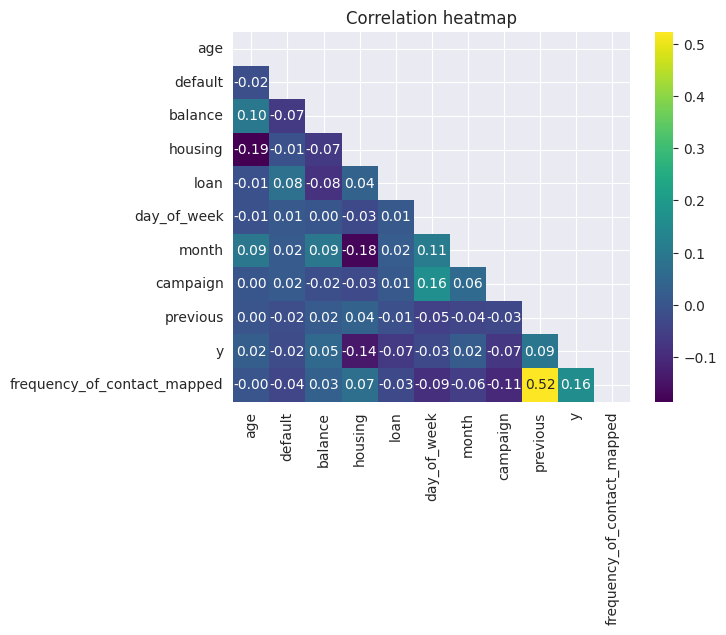

In [98]:


def plot_heatmap(data:pd.DataFrame):
  # Select only numeric columns for correlation calculation
  numeric_data = data.select_dtypes(include=np.number)
  corr = numeric_data.corr()
  mask = np.triu(np.ones_like(corr,dtype=bool))
  plt.title("Correlation heatmap")
  sns.heatmap(data=corr,mask=mask,cmap="viridis",fmt=".2f",annot=True)
  plt.show()

plot_heatmap(dataframe_binary)

In [97]:
importances = best_pipeline.named_steps["model"].feature_importances_

feat_imp = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
}).sort_values(by="importance", ascending=False)

feat_imp.head(10)

,feature,importance
5,campaign,0.186416
4,month,0.172551
3,day_of_week,0.081173
2,balance,0.078627
0,age,0.065195
6,previous,0.062970
31,contact_unknown,0.058143
7,frequency_of_contact_mapped,0.048050
25,housing_0,0.046564
26,housing_1,0.041843
